### Import

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family="Malgun Gothic")
plt.rcParams['axes.unicode_minus'] = False

In [151]:
train_df = pd.read_csv("Data/train.csv").drop(columns=['ID'])
test_df = pd.read_csv("Data/test.csv").drop(columns=['ID'])
train_X = train_df.drop(["임신 성공 여부"], axis=1)
y = train_df["임신 성공 여부"]

In [152]:
def drop_high_missing_columns(df:pd.DataFrame, threshold=0.8):
    to_drop = df.columns[df.isnull().mean() > threshold]
    return df.drop(columns=to_drop), to_drop.tolist()

train_X, dropped_columns = drop_high_missing_columns(train_X, threshold=0.8)
print(dropped_columns)
test_df, dropped_columns = drop_high_missing_columns(test_df, threshold=0.8)
print(dropped_columns)

['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']
['임신 시도 또는 마지막 임신 경과 연수', '착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '배아 해동 경과일']


In [153]:
categorical_cols = train_X.select_dtypes(include=['object']).columns
numerical_cols = train_X.select_dtypes(include=['float64','int64']).columns

In [154]:
print(train_X.columns[train_X.isnull().sum()>0])
print(test_df.columns[test_df.isnull().sum()>0])

Index(['특정 시술 유형', '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '배아 생성 주요 이유',
       '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
       '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
       '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수',
       '기증자 정자와 혼합된 난자 수', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
       '대리모 여부', '난자 채취 경과일', '난자 혼합 경과일', '배아 이식 경과일'],
      dtype='object')
Index(['단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '배아 생성 주요 이유', '총 생성 배아 수',
       '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
       '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수',
       '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '동결 배아 사용 여부',
       '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', '난자 채취 경과일', '난자 혼합 경과일',
       '배아 이식 경과일'],
      dtype='object')


In [155]:
train_miss = train_X[categorical_cols].isnull().sum()
train_miss = train_miss[train_miss > 0] 
train_miss

특정 시술 유형          2
배아 생성 주요 이유    6291
dtype: int64

In [156]:
num_miss = train_X[numerical_cols].isnull().sum()
num_miss = num_miss[num_miss > 0] 
num_miss

단일 배아 이식 여부          6291
착상 전 유전 진단 사용 여부     6291
총 생성 배아 수            6291
미세주입된 난자 수           6291
미세주입에서 생성된 배아 수      6291
이식된 배아 수             6291
미세주입 배아 이식 수         6291
저장된 배아 수             6291
미세주입 후 저장된 배아 수      6291
해동된 배아 수             6291
해동 난자 수              6291
수집된 신선 난자 수          6291
저장된 신선 난자 수          6291
혼합된 난자 수             6291
파트너 정자와 혼합된 난자 수     6291
기증자 정자와 혼합된 난자 수     6291
동결 배아 사용 여부          6291
신선 배아 사용 여부          6291
기증 배아 사용 여부          6291
대리모 여부               6291
난자 채취 경과일           57488
난자 혼합 경과일           53735
배아 이식 경과일           43566
dtype: int64

In [157]:
train_X[categorical_cols] = train_X[categorical_cols].fillna('Unknown')
test_df[categorical_cols] = test_df[categorical_cols].fillna('Unknown')

DI = train_X[train_X['시술 유형'] == "DI"].copy()
DI_T = test_df[test_df['시술 유형'] == "DI"].copy()

DI[numerical_cols] = DI[numerical_cols].fillna(0)
DI_T[numerical_cols] = DI_T[numerical_cols].fillna(0)

train_X.loc[train_X['시술 유형'] == "DI", numerical_cols] = DI[numerical_cols]
test_df.loc[test_df['시술 유형'] == "DI", numerical_cols] = DI_T[numerical_cols]


In [158]:
num_miss = train_X[numerical_cols].isnull().sum()
num_miss = num_miss[num_miss > 0] 
num_miss

난자 채취 경과일    51197
난자 혼합 경과일    47444
배아 이식 경과일    37275
dtype: int64

In [159]:
train_X = train_X.drop(columns=["난자 채취 경과일"])
test_df = test_df.drop(columns=["난자 채취 경과일"])

train_X[['배아 이식 경과일',"난자 혼합 경과일"]] = train_X[['배아 이식 경과일',"난자 혼합 경과일"]].fillna(0)
test_df[['배아 이식 경과일',"난자 혼합 경과일"]] = test_df[['배아 이식 경과일',"난자 혼합 경과일"]].fillna(0)


In [160]:
categorical_cols = train_X.select_dtypes(include=['object']).columns
numerical_cols = train_X.select_dtypes(include=['float64','int64']).columns

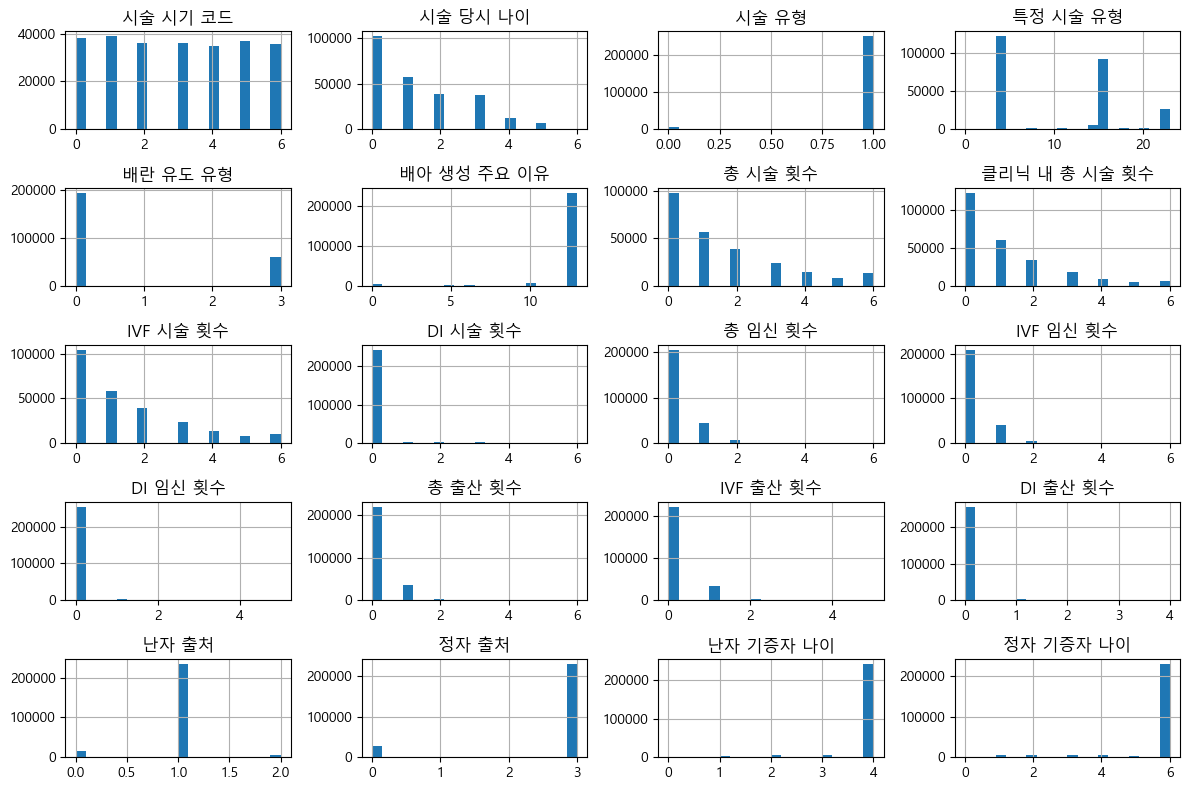

In [161]:
train_X[categorical_cols].apply(lambda x: x.astype('category').cat.codes).hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

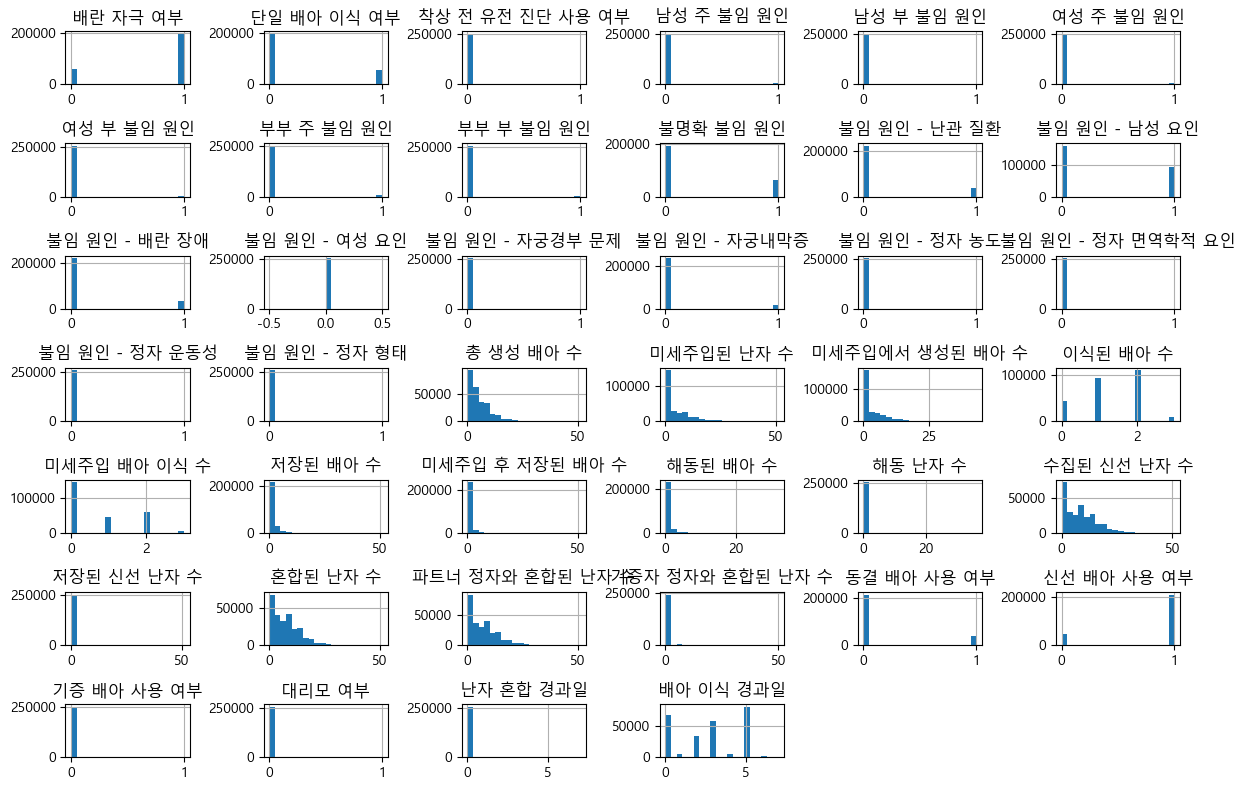

In [162]:
train_X[numerical_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

In [163]:
unique_values = {col: train_X[col].unique() for col in train_X.columns}

# 결과 출력
for col, values in unique_values.items():
    print(f"{col}")
    print(values[:])

시술 시기 코드
['TRZKPL' 'TRYBLT' 'TRVNRY' 'TRJXFG' 'TRXQMD' 'TRCMWS' 'TRDQAZ']
시술 당시 나이
['만18-34세' '만45-50세' '만35-37세' '만38-39세' '만40-42세' '만43-44세' '알 수 없음']
시술 유형
['IVF' 'DI']
특정 시술 유형
['ICSI' 'IVF' 'Unknown' 'IUI' 'IVF:IVF' 'IVF / BLASTOCYST' 'ICSI:IVF'
 'ICSI / AH' 'ICSI:ICSI' 'IVF:ICSI' 'ICSI / BLASTOCYST ' 'IVF:Unknown'
 'ICSI:Unknown' 'IVF / AH' 'IVI' 'Generic DI'
 'ICSI / BLASTOCYST :IVF / BLASTOCYST' 'ICI' 'IVF / AH:ICSI / AH' 'GIFT'
 'ICSI / BLASTOCYST:IVF / BLASTOCYST' 'ICSI / AH:Unknown' 'FER'
 'ICSI / BLASTOCYST :ICSI']
배란 자극 여부
[1 0]
배란 유도 유형
['기록되지 않은 시행' '알 수 없음' '세트로타이드 (억제제)' '생식선 자극 호르몬']
단일 배아 이식 여부
[0. 1.]
착상 전 유전 진단 사용 여부
[0. 1.]
남성 주 불임 원인
[0 1]
남성 부 불임 원인
[0 1]
여성 주 불임 원인
[0 1]
여성 부 불임 원인
[0 1]
부부 주 불임 원인
[0 1]
부부 부 불임 원인
[0 1]
불명확 불임 원인
[0 1]
불임 원인 - 난관 질환
[0 1]
불임 원인 - 남성 요인
[1 0]
불임 원인 - 배란 장애
[1 0]
불임 원인 - 여성 요인
[0]
불임 원인 - 자궁경부 문제
[0 1]
불임 원인 - 자궁내막증
[0 1]
불임 원인 - 정자 농도
[0 1]
불임 원인 - 정자 면역학적 요인
[0 1]
불임 원인 - 정자 운동성
[0 1]
불임 원인 - 정자 형태
[0 1]
배아 생성 주요 이유
['현재 시술용'

In [164]:
train_X['특정 시술 유형'] = train_X['특정 시술 유형'].astype(str).str.strip()
train_X['특정 시술 유형'] = train_X['특정 시술 유형'].str.replace(r'\s+', '', regex=True)
train_X["특정 시술 유형"] = train_X["특정 시술 유형"].str.split(":").str[0] 
test_df['특정 시술 유형'] = test_df['특정 시술 유형'].astype(str).str.strip()
test_df['특정 시술 유형'] = test_df['특정 시술 유형'].str.replace(r'\s+', '', regex=True)
test_df["특정 시술 유형"] = test_df["특정 시술 유형"].str.split(":").str[0] 
unique_values = train_X["특정 시술 유형"].unique()
print(unique_values) 

['ICSI' 'IVF' 'Unknown' 'IUI' 'IVF/BLASTOCYST' 'ICSI/AH' 'ICSI/BLASTOCYST'
 'IVF/AH' 'IVI' 'GenericDI' 'ICI' 'GIFT' 'FER']


In [165]:
# 배아 생성 주요 이유 컬럼의 값 정렬하여 고유값 개수 줄이기
train_X["배아 생성 주요 이유"] = (
    train_X["배아 생성 주요 이유"]
    .str.replace(" ", "")  # 공백 제거
    .str.split(",")  # 쉼표 기준으로 분할
    .apply(lambda x: ",".join(sorted(x)))  # 정렬 후 다시 합치기
)
test_df["배아 생성 주요 이유"] = (
    test_df["배아 생성 주요 이유"]
    .str.replace(" ", "")  # 공백 제거
    .str.split(",")  # 쉼표 기준으로 분할
    .apply(lambda x: ",".join(sorted(x)))  # 정렬 후 다시 합치기
)

# 변환된 고유값 목록 출력
unique_values = test_df["배아 생성 주요 이유"].unique()
print(unique_values)

['현재시술용' 'Unknown' '배아저장용' '배아저장용,현재시술용' '기증용,현재시술용' '난자저장용' '기증용'
 '기증용,배아저장용' '기증용,난자저장용' '기증용,배아저장용,현재시술용' '난자저장용,현재시술용' '난자저장용,배아저장용']


In [166]:
# train_X['배란 유도 유형'] = train_X['배란 유도 유형'].replace({
#     '생식선 자극 호르몬': '약물유도',
#     '세트로타이드 (억제제)': '약물유도',
#     '기록되지 않은 시행': 'Unknown',
#     '알 수 없음': 'Unknown'
# })
# test_df['배란 유도 유형'] = test_df['배란 유도 유형'].replace({
#     '생식선 자극 호르몬': '약물유도',
#     '세트로타이드 (억제제)': '약물유도',
#     '기록되지 않은 시행': 'Unknown',
#     '알 수 없음': 'Unknown'
# })

In [167]:
# 범주화 기준 설정
def categorize_days(value):
    if value == 0:
        return "0일"
    elif value in [1, 2, 3]:
        return "1-3일"
    elif value in [4, 5, 6]:
        return "4-6일"
    elif value == 7:
        return "7일"
    return "Unknown"  # 혹시 모를 예외 처리

columns_to_categorize = ["배아 이식 경과일"]
for col in columns_to_categorize:
    train_X[col] = train_X[col].apply(categorize_days)
    test_df[col] = test_df[col].apply(categorize_days)


In [168]:
unique_values = {col: train_X[col].unique() for col in train_X.columns}

# 결과 출력
for col, values in unique_values.items():
    print(f"{col}")
    print(values[:])

시술 시기 코드
['TRZKPL' 'TRYBLT' 'TRVNRY' 'TRJXFG' 'TRXQMD' 'TRCMWS' 'TRDQAZ']
시술 당시 나이
['만18-34세' '만45-50세' '만35-37세' '만38-39세' '만40-42세' '만43-44세' '알 수 없음']
시술 유형
['IVF' 'DI']
특정 시술 유형
['ICSI' 'IVF' 'Unknown' 'IUI' 'IVF/BLASTOCYST' 'ICSI/AH' 'ICSI/BLASTOCYST'
 'IVF/AH' 'IVI' 'GenericDI' 'ICI' 'GIFT' 'FER']
배란 자극 여부
[1 0]
배란 유도 유형
['기록되지 않은 시행' '알 수 없음' '세트로타이드 (억제제)' '생식선 자극 호르몬']
단일 배아 이식 여부
[0. 1.]
착상 전 유전 진단 사용 여부
[0. 1.]
남성 주 불임 원인
[0 1]
남성 부 불임 원인
[0 1]
여성 주 불임 원인
[0 1]
여성 부 불임 원인
[0 1]
부부 주 불임 원인
[0 1]
부부 부 불임 원인
[0 1]
불명확 불임 원인
[0 1]
불임 원인 - 난관 질환
[0 1]
불임 원인 - 남성 요인
[1 0]
불임 원인 - 배란 장애
[1 0]
불임 원인 - 여성 요인
[0]
불임 원인 - 자궁경부 문제
[0 1]
불임 원인 - 자궁내막증
[0 1]
불임 원인 - 정자 농도
[0 1]
불임 원인 - 정자 면역학적 요인
[0 1]
불임 원인 - 정자 운동성
[0 1]
불임 원인 - 정자 형태
[0 1]
배아 생성 주요 이유
['현재시술용' 'Unknown' '난자저장용' '배아저장용' '기증용,현재시술용' '기증용,배아저장용' '기증용'
 '기증용,난자저장용' '배아저장용,현재시술용' '난자저장용,배아저장용' '기증용,배아저장용,현재시술용' '연구용,현재시술용'
 '난자저장용,현재시술용' '난자저장용,배아저장용,연구용']
총 시술 횟수
['0회' '1회' '2회' '6회 이상' '3회' '4회' '5회']
클리닉 내 총 시술 횟수
['0회' 

In [169]:
train_cleaned = pd.concat([train_X, y], axis=1).drop_duplicates()

train_cleaned.to_csv("train_c.csv", index=False, encoding='utf-8-sig')
test_df.to_csv("test_c.csv", index=False, encoding='utf-8-sig')